In [1]:
import os
from openai import OpenAI
import base64
from io import BytesIO
from IPython.display import HTML, display
from PIL import Image, ImageDraw, ImageFont
import io
import cv2
import numpy as np
from pydantic import BaseModel
from typing import Tuple, List


In [2]:
def convert_to_base64(img):
    """
    Convert PIL images to Base64 encoded strings

    :param pil_image: PIL image
    :return: Re-sized Base64 string
    """

    buffered = BytesIO()
    img.save(buffered, format="PNG")  # You can change the format if needed
    img_str = base64.b64encode(buffered.getvalue()).decode("utf-8")
    return img_str

def draw_axes_opencv(img, font_scale, grid_size=(4, 4)):
    """
    Draw axes and row/column labels with contours on an image using OpenCV.

    :param img: PIL Image
    :param font_scale: Scale factor for the font size
    :param grid_size: Tuple indicating (rows, cols) of the grid
    :return: PIL Image with axes and row/column labels
    """
    
    # Convert PIL image to NumPy array (for OpenCV)
    img_cv = np.array(img)
    
    # If image has alpha channel, convert it to BGR
    if img_cv.shape[2] == 4:
        img_cv = cv2.cvtColor(img_cv, cv2.COLOR_RGBA2RGB)
    
    height, width, _ = img_cv.shape
    
    # Calculate cell size based on the grid size
    rows, cols = grid_size
    cell_width = width // cols
    cell_height = height // rows
    
    # Define grid line color and thickness
    grid_color = (255, 0, 0)  # Blue in BGR
    if width > 400:
        grid_thickness = 2
    else:
        grid_thickness = 1
    
    # Draw the vertical grid lines
    for i in range(1, cols):
        x = i * cell_width
        cv2.line(img_cv, (x, 0), (x, height), grid_color, grid_thickness)
    
    # Draw the horizontal grid lines
    for i in range(1, rows):
        y = i * cell_height
        cv2.line(img_cv, (0, y), (width, y), grid_color, grid_thickness)
    
    # Define text properties
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_color = (255, 255, 255)  # White text
    contour_color = (0, 0, 0)      # Black contour for better visibility
    font_scale_adjusted = min(cell_width, cell_height) / 100
    if width > 400:
        font_thickness = 2          # Thickness for the fill text
        contour_thickness = 6       # Thickness for the contour
    else:
        font_thickness = 1
        contour_thickness = 4      # Thickness for the contour

    
    # -----------------------
    # Add Column Labels (Top)
    # -----------------------
    for col in range(cols):
        # Define column label as a number (1, 2, 3, ...)
        col_label = str(col + 1)
        text = col_label
        
        # Get the text size to center it properly within the cell
        (text_width, text_height), baseline = cv2.getTextSize(text, font, font_scale_adjusted, font_thickness)
        
        # Calculate the position: center of the top cell
        center_x = col * cell_width + (cell_width - text_width) // 2
        center_y = (cell_height + text_height) // 2  # Slight padding from the top
        
        # Draw contour (outline) by drawing the text in contour color with higher thickness
        cv2.putText(img_cv, text, (center_x, center_y), font, font_scale_adjusted, contour_color, contour_thickness, cv2.LINE_AA)
        
        # Draw the text in the fill color with lower thickness
        cv2.putText(img_cv, text, (center_x, center_y), font, font_scale_adjusted, font_color, font_thickness, cv2.LINE_AA)
    
    # -----------------------
    # Add Row Labels (Left)
    # -----------------------
    for row in range(rows):
        # Define row label as a number (1, 2, 3, ...)
        row_label = str(row + 1)
        text = row_label
        
        # Get the text size to center it properly within the cell
        (text_width, text_height), baseline = cv2.getTextSize(text, font, font_scale_adjusted, font_thickness)
        
        # Calculate the position: center of the left cell
        center_x = (cell_width - text_width) // 2
        center_y = row * cell_height + (cell_height + text_height) // 2
        
        # Draw contour (outline) by drawing the text in contour color with higher thickness
        cv2.putText(img_cv, text, (center_x, center_y), font, font_scale_adjusted, contour_color, contour_thickness, cv2.LINE_AA)
        
        # Draw the text in the fill color with lower thickness
        cv2.putText(img_cv, text, (center_x, center_y), font, font_scale_adjusted, font_color, font_thickness, cv2.LINE_AA)
    
    # -----------------------
    # Optional: Highlight Top-Left Cell
    # -----------------------
    # If you want to leave the top-left cell blank or add a special label (like a corner indicator), uncomment the following lines:
    # top_left_cell = (0, 0)
    # cv2.rectangle(img_cv, (0, 0), (cell_width, cell_height), grid_color, grid_thickness)
    # Alternatively, add a special label:
    # corner_label = "X"  # Or any other symbol
    # (text_width, text_height), baseline = cv2.getTextSize(corner_label, font, font_scale_adjusted, font_thickness)
    # text_x = (cell_width - text_width) // 2
    # text_y = (cell_height + text_height) // 2
    # cv2.putText(img_cv, corner_label, (text_x, text_y), font, font_scale_adjusted, contour_color, contour_thickness, cv2.LINE_AA)
    # cv2.putText(img_cv, corner_label, (text_x, text_y), font, font_scale_adjusted, font_color, font_thickness, cv2.LINE_AA)
    
    # Convert back to PIL Image
    return Image.fromarray(img_cv)

def add_white_contour_opencv(img, font_scale=2):
    """
    Add a white background and labels to an image using OpenCV
    """
    # Convert PIL image to NumPy array (for OpenCV)
    img_cv = np.array(img)
    height, width, _ = img_cv.shape
    # Add padding for the white contour
    size = int(width * 0.11)
    new_img = np.full((height + size, width + size, 3), (255, 255, 255), dtype=np.uint8)
    new_img[size:, size:] = img_cv
    
    # Add the label using OpenCV
    cv2.putText(new_img, "(0, 0)", (int(size*0.2), int(size*0.6)), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 0, 0), 2)
    cv2.putText(new_img, f"{height//4}", (int(size*0.4), height//4+size), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 0, 0), 2)
    cv2.putText(new_img, f"{height}", (int(size*0.4), height+int(size*0.9)), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 0, 0), 2)
    cv2.putText(new_img, f"{height//2}", (int(size*0.4), height//2+size), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 0, 0), 2)
    cv2.putText(new_img, f"{(height//2)+(height//4)}", (int(size*0.4), (height//2)+(height//4)+size), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 0, 0), 2)

    cv2.putText(new_img, f"{width}", (width+int(size*0.4), int(size*0.6)), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 0, 0), 2)
    cv2.putText(new_img, f"{width//4}", (width//4+int(size*0.8), int(size*0.6)), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 0, 0), 2)
    cv2.putText(new_img, f"{width//2}", (width//2+int(size*0.8), int(size*0.6)), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 0, 0), 2)
    cv2.putText(new_img, f"{(width//4)+(width//2)}", ((width//4)+(width//2)+int(size*0.8), int(size*0.6)), cv2.FONT_HERSHEY_SIMPLEX, font_scale, (255, 0, 0), 2)
    # Convert back to PIL image
    return Image.fromarray(new_img)

def pre_process_image_opencv(img, boxes, font_scale=0.0007):
    """
    Pre-process an image before displaying it with OpenCV

    :param img: PIL image
    :return: PIL image with axes, quadrants, and white contour
    """
    font_scale = img.size[0] * font_scale
    img = draw_axes_opencv(img, font_scale)
    if boxes:
        img = draw_bounding_boxes(img, boxes)
    #img = add_white_contour_opencv(img, font_scale)
    return img

def reduce_image_size(image, max_size=500):
    """
    Reduce the size of an image while maintaining the aspect ratio

    :param image: PIL image
    :param max_size: Maximum size for the image
    :return: Resized PIL image
    """
    width, height = image.size
    if width > height:
        new_width = max_size
        new_height = int(max_size * height / width)
    else:
        new_height = max_size
        new_width = int(max_size * width / height)
    return image.resize((new_width, new_height))

def reduce_resolution(image, resample_filter=Image.NEAREST):
    """
    Lower the resolution of the image by applying a resample filter.
    :param image: PIL image
    :param resample_filter: Resampling filter to use (default: Image.NEAREST for lower quality)
    :return: Lower resolution PIL image
    """
    # Applying the selected filter for downsampling
    width, height = image.size
    return image.resize((width, height), resample=resample_filter)

def process(image, reduce_resolution=False, reduce_size=True, boxes=None):
    
    image = pre_process_image_opencv(image, boxes)

    if reduce_size:
        image = reduce_image_size(image)
    if reduce_resolution:
        image = reduce_resolution(image)
        
    image_base64 = convert_to_base64(image)
    return image_base64

def save_img(image, path):
    image.save(path)

def draw_bounding_boxes(image, boxes):
    """
    Draws bounding boxes on an image.

    :param image: PIL image object
    :param boxes: List of tuples, each tuple containing (x1, y1, x2, y2) 
                  which represent the top-left and bottom-right corners of a box
    :return: Image with bounding boxes drawn
    """
    
    # Create a drawing context
    image_copy = image.copy()
    draw = ImageDraw.Draw(image_copy)
    
    # Loop through each box in the list
    for box in boxes:
        x1, y1, x2, y2 = box
        
        # Draw rectangle with a red outline (you can adjust color and width)
        draw.rectangle([x1, y1, x2, y2], outline="green", width=4)
    
    return image_copy

def plt_image(image):
    display(HTML(f'<img src="data:image/png;base64,{image}">'))

def get_cells(response):
    return [response.cell_numbers[0].top, response.cell_numbers[0].bottom, response.cell_numbers[0].left, response.cell_numbers[0].right]

def calculate_box_from_cells(image, columns, rows, grid_size=(4, 4)):
    width, height = image.size
    total_cols, total_rows = grid_size
    cell_width = width // total_cols
    cell_height = height // total_rows

    left = (min(columns) - 1) * cell_width
    right = max(columns) * cell_width
    top = (min(rows) - 1) * cell_height
    bottom = max(rows) * cell_height

    return (left, top, right, bottom)

def crop_image(image, cells, grid_size=(4, 4)):
    """
    Crop an image by including only specified rows and columns.

    :param image: PIL Image
    :param included_rows: List of row indices to include (1-based)
    :param included_columns: List of column indices to include (1-based)
    :param grid_size: Tuple indicating (rows, cols) of the grid (default is 4x4)
    :return: Cropped PIL Image
    """
    included_columns, included_rows = cells[0]
    rows, cols = grid_size
    cell_width = image.size[0] // cols
    cell_height = image.size[1] // rows

    # Calculate new image dimensions
    new_width = cell_width * len(included_columns)
    new_height = cell_height * len(included_rows)

    # Create a new blank image with the same mode as the original
    new_image = Image.new(image.mode, (new_width, new_height))

    # Iterate over included rows and columns to paste cells into the new image
    for i, row in enumerate(included_rows):
        for j, col in enumerate(included_columns):
            left = (col - 1) * cell_width
            upper = (row - 1) * cell_height
            right = left + cell_width
            lower = upper + cell_height

            # Crop the specific cell
            cell = image.crop((left, upper, right, lower))
            
            # Paste the cell into the new image
            new_image.paste(cell, (j * cell_width, i * cell_height))
    new_image = resize_to_min_dimension(new_image)

    return new_image

def split_image_into_tiles(image, tile_size=(256, 256), overlap=0.2):
    """
    Splits the image into overlapping tiles.
    :param image: PIL Image
    :param tile_size: Tuple indicating the (width, height) of each tile
    :param overlap: Fractional overlap between tiles (0 to 1)
    :return: List of tiles along with their positions in the original image
    """
    width, height = image.size
    tile_width, tile_height = tile_size
    step_x = int(tile_width * (1 - overlap))
    step_y = int(tile_height * (1 - overlap))

    tiles = []
    positions = []

    for x in range(0, width - tile_width + 1, step_x):
        for y in range(0, height - tile_height + 1, step_y):
            box = (x, y, x + tile_width, y + tile_height)
            tile = image.crop(box)
            tiles.append(tile)
            positions.append(box)

    return tiles, positions

def resize_to_min_dimension(img, min_size=200):
    """
    Resizes an image so that its smallest dimension is at least min_size pixels,
    while maintaining the aspect ratio.

    :param img: PIL Image object
    :param min_size: The minimum size for the smallest dimension (default is 200)
    :return: Resized PIL Image object
    """
    width, height = img.size

    # Check if resizing is necessary
    if width >= min_size and height >= min_size:
        # No resizing needed
        return img
    else:
        # Calculate the scaling factor
        if width < height:
            scale_factor = min_size / width
        else:
            scale_factor = min_size / height

        # Calculate new dimensions
        new_width = int(round(width * scale_factor))
        new_height = int(round(height * scale_factor))

        # Resize the image with high-quality resampling
        resized_img = img.resize((new_width, new_height), Image.LANCZOS)

        return resized_img

def non_max_suppression_fast(boxes, overlapThresh=0.3):
    """
    Perform Non-Maximum Suppression to merge overlapping bounding boxes.
    :param boxes: List of dictionaries with 'box' and 'label'
    :param overlapThresh: IoU threshold for suppression
    :return: List of merged bounding boxes
    """
    import numpy as np

    if len(boxes) == 0:
        return []

    # Convert bounding boxes to NumPy array
    boxes_array = np.array([b['box'] for b in boxes])
    labels = [b['label'] for b in boxes]

    # Initialize the list of picked indexes
    pick = []

    # Grab the coordinates
    x1 = boxes_array[:, 0]
    y1 = boxes_array[:, 1]
    x2 = boxes_array[:, 2]
    y2 = boxes_array[:, 3]

    # Compute the area of the bounding boxes
    areas = (x2 - x1 + 1) * (y2 - y1 + 1)

    # Sort the bounding boxes by the bottom-right y-coordinate
    idxs = np.argsort(y2)

    while len(idxs) > 0:
        # Grab the last index in idxs (its position)
        last = len(idxs) - 1
        i = idxs[last]
        pick.append(i)

        # Find the intersection points
        xx1 = np.maximum(x1[i], x1[idxs[:last]])
        yy1 = np.maximum(y1[i], y1[idxs[:last]])
        xx2 = np.minimum(x2[i], x2[idxs[:last]])
        yy2 = np.minimum(y2[i], y2[idxs[:last]])

        # Compute the width and height of the intersection rectangle
        w = np.maximum(0, xx2 - xx1 + 1)
        h = np.maximum(0, yy2 - yy1 + 1)

        # Compute the ratio of overlap (IoU)
        overlap = (w * h) / areas[idxs[:last]]

        # Delete indexes with overlap greater than the threshold
        idxs = np.delete(
            idxs,
            np.concatenate(
                ([last], np.where(overlap > overlapThresh)[0])
            )
        )

    # Return the picked bounding boxes
    merged_boxes = [{'box': boxes_array[p], 'label': labels[p]} for p in pick]
    return merged_boxes

# Update the process_tiles function to use NMS
def process_tiles(client, image, tile_size=(256, 256), overlap=0.2):
    tiles, positions = split_image_into_tiles(image, tile_size, overlap)
    all_boxes = []

    for tile, position in zip(tiles, positions):
        # Process the tile
        tile_processed = process(tile)
        tile_overlayed = process(tile)

        # Ask LLM to detect objects in the tile
        response = ask_llm_to_detect_ui_tile(client, convert_to_base64(tile), tile_processed)

        # Process the response and calculate bounding boxes for detected objects
        if hasattr(response, 'cell_numbers'):
            for obj in response.cell_numbers:
                cols = obj.columns
                rows = obj.rows
                if cols and rows:
                    box = calculate_box_from_cells(tile, cols, rows)
                    # Adjust the box coordinates relative to the original image
                    adjusted_box = (
                        box[0] + position[0],
                        box[1] + position[1],
                        box[2] + position[0],
                        box[3] + position[1],
                    )
                    all_boxes.append({'box': adjusted_box, 'label': obj.label})

    # Perform Non-Maximum Suppression on all boxes
    merged_boxes = non_max_suppression_fast(all_boxes, overlapThresh=0.3)
    return merged_boxes

In [19]:
#image_path = 'test.png'
example_path = 'Zidane from Ultralytics.jpg'
example = Image.open(example_path)

In [20]:
image_path = 'people_1.jpg'
image = Image.open(image_path)


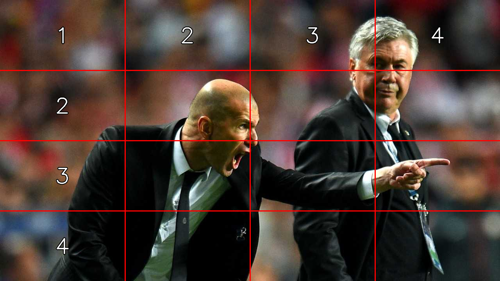


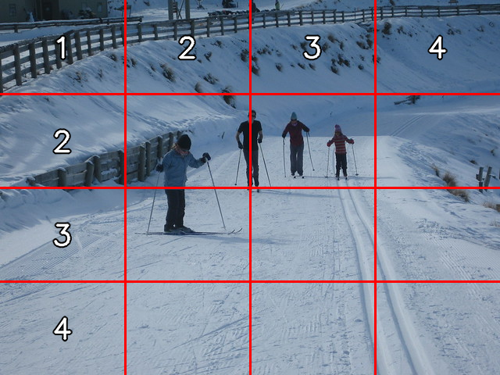

In [21]:
plt_image(process(example))
plt_image(process(image))

In [22]:
image_processed = process(image)
example_processed = process(example)

In [7]:
class MultiDetection(BaseModel):
    multiple_instances: bool

# Function to ask LLM to detect UI elements and return bounding boxes
def detect_number_of_instances(client, image, max_tokens=500):
    response = client.beta.chat.completions.parse(
        model="gpt-4o-2024-08-06",
        messages=[
            {"role": "system", "content": [
                                    {
                                    "type": "text",
                                    "text": """
                                            You are a computer vision model that can count objects in images. You have the simple task of 
                                            detecting whether an image contains multiple instances of a given object or not. You have to return:
                                                - True if there are multiple instances of the object
                                                - False if there is only one instance
                                                - None if there are no instances.
                                            """,
                                    },

                ]},
            {
            "role": "user",
            "content": [
                {
                "type": "text",
                "text": "Detect the people in the image below:",
                },
                {
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/jpeg;base64,{image}",
                },
                },
            ],
            }
        ],
        max_tokens=max_tokens,
        response_format=MultiDetection,
        )
    #print(response)
    return response.choices[0].message.parsed

In [8]:
class ColRows(BaseModel):
    columns: list[int]
    rows: list[int]


class MultiCrop(BaseModel):
    contains_objects: ColRows
    done: bool

# Function to ask LLM to detect UI elements and return bounding boxes
def crop_all_instances(client, example, image, overlayed_image, max_tokens=500):
    response = client.beta.chat.completions.parse(
        model="gpt-4o-2024-08-06",
        messages=[
            {"role": "system", "content": [
                                    {
                                    "type": "text",
                                    "text": """
                                            You are a computer vision model that detects objects in images. 
                                            The image has a 4x4 grid overlay with the columns and rows numbered. Note that the numbers are inside the cells. 
                                            You have to follow these steps: 
                                                - Detect which of the 4 columns contain at least one part of ANY of the detected objects.
                                                - Detect which of the 4 rows contain at least one part of ANY of the detected object.
                                                - Return the columns and rows.
                                            
                                            Set the variable 'done' to True if ALL rows and ALL columns contain at least one part of an object.

                                            Ensure you reference the columns and rows numbers as they appear on the grid overlay 
                                            in the image. If there are ANY rows or columns that don't contain any part of the objects,
                                            return False for the variable 'done.' But if ALL rows and columns contain at least one part of the objects,
                                            return True for the variable 'done.'
                                            **IMPORTANT**: Make sure to compare the original image with the image with the grid overlay to know what exactly constitutes the objects to detect.
                                            A cell is considered to contain a part of the object if there is at least a small part of the object in the cell.
                                            The columns and rows numnering starts from 1 and the numbers are placed INSIDE the grid. The top-left cell is 1 for both rows and columns.
                                            **Make sure to check that the objects are not cut off by the grid lines. If they are, consider the object to be in the cell and include the respective column/row in your answer.**
                                            """,
                                    },

                ]},
            {
            "role": "user",
            "content": [
                {
                "type": "text",
                "text": f"Detect the people in this image. Here you have the original image for your reference and the image with the grid cells. Make sure to compare both images so that you know what exactly constitutes the object to detect:",
                },
                {
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/jpeg;base64,{image}",
                },
                },
                {
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/jpeg;base64,{overlayed_image}",
                },
                },
                                {
                "type": "text",
                "text": """
                        Here you have an example of how to do this: you are asked to detect the people in the image below:  
                        """,
                },
                {
                "type": "image_url",
                "image_url": {
                    "url": f"data:image/jpeg;base64,{example}",
                },
                },
                {
                "type": "text",
                "text": """
                        Then your response would be:
                        Columns: [1, 2, 3, 4] - because all columns contain at least a part of a person
                        Rows: [1, 2, 3, 4] - because both persons can be found in rows 2, 3, 4 and the head of the person on the right can be found in row 1
                        Done: True - because ALL rows AND columns contain at least a part of a person, otherwise it would be False. 
                        NOTE: The anwer columns and rows don't cut off any part of the persons.
                        """,
                },
            ],
            }
        ],
        max_tokens=max_tokens,
        response_format=MultiCrop,
        )
    #print(response)
    return response.choices[0].message.parsed

In [9]:
class Box(BaseModel):
    columns: list[int]
    rows: list[int]
    label: str
class Response(BaseModel):
    cell_numbers: list[Box]
    
def ask_llm_to_detect_ui_tile(client, tile_image_base64, overlayed_tile_base64, max_tokens=500):
    response = client.beta.chat.completions.parse(
        model="gpt-4o-2024-08-06",
        messages=[
            {"role": "system", "content": [
                {
                    "type": "text",
                    "text": """
                    You are a computer vision model that detects objects in images.
                    The image has a grid overlay with numbered columns and rows.
                    For each object detected in the image:
                    1. Identify which columns and rows contain parts of the object.
                    2. Return the columns and rows for each object detected.
                    3. Provide the label for each detection.
                    Only report actual objects that the user requests in the image. Ignore any false positives or partial detections.
                    Be precise in your detections to avoid overlapping bounding boxes for the same object.
                    """,
                },
            ]},
            {
                "role": "user",
                "content": [
                    {
                        "type": "text",
                        "text": f"Detect all the people in this image tile. Here is the image tile and the same tile with grid overlay:",
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/jpeg;base64,{tile_image_base64}",
                        },
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/jpeg;base64,{overlayed_tile_base64}",
                        },
                    },
                ],
            }
        ],
        max_tokens=max_tokens,
        response_format=Response,
    )
    return response.choices[0].message.parsed

In [10]:
# Main process
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])


In [11]:
response = detect_number_of_instances(client, image_processed)

In [12]:
response

MultiDetection(multiple_instances=True)


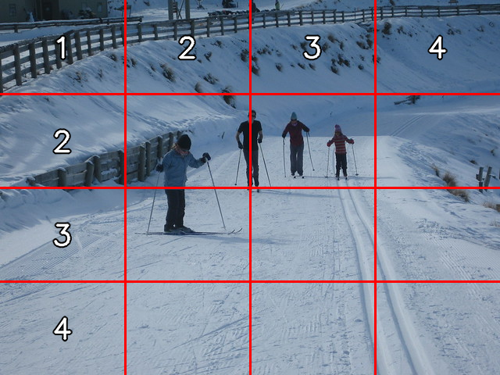

0



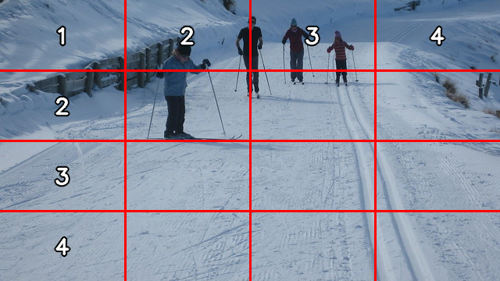

1



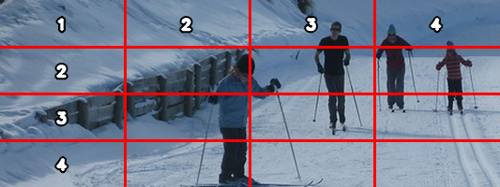

2



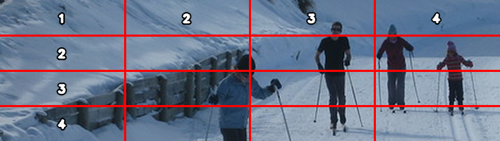

In [23]:
#multiple_instances = response.multiple_instances
multiple_instances = True
cells = []
image_ = image
plt_image(image_processed)
if multiple_instances and multiple_instances is not None:
    for i in range(3):
        print(i)
        response = crop_all_instances(client, example_processed, convert_to_base64(image_), image_processed)
        if response.done:
            break
        col = response.contains_objects.columns
        row = response.contains_objects.rows
    
        cells.append([(col, row)])
        image_ = crop_image(image_, cells[i])
        image_processed = process(image_)
        plt_image(image_processed)


In [24]:
edge=int(min(image_.size)*0.75)

In [25]:
tile_size = (edge, edge)

In [26]:
merged_boxes = process_tiles(client, image_, tile_size=tile_size, overlap=0.2)

# Optionally filter bounding boxes
# merged_boxes = filter_boxes(merged_boxes, min_size=1000)



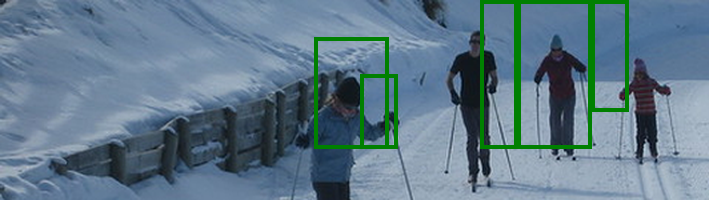

In [27]:
# Draw bounding boxes on the original image
final_image = draw_bounding_boxes(image_, [b['box'] for b in merged_boxes])
save_img(final_image, "detected_multiple_objects.jpg")
final_image